# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Wine Quality (Red)** dari UCI Machine Learning Repository.

- **Sumber**: [UCI ML Repository](https://archive.ics.uci.edu/dataset/186/wine+quality)
- **Jumlah data**: 1599 sampel
- **Jumlah fitur**: 11 fitur input + 1 target (quality)
- **Tipe problem**: Multi-class Classification
- **Tujuan**: Memprediksi kualitas wine (skala 3-8) berdasarkan sifat fisikokimia


# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka yang dibutuhkan untuk analisis data dan pembangunan model machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("Library berhasil diimpor!")


Library berhasil diimpor!


# **3. Memuat Dataset**

Memuat dataset Wine Quality (Red) dari file CSV. Dataset ini menggunakan separator semicolon (;).


In [2]:
df = pd.read_csv("../winequality-red.csv", sep=";")

print("Shape dataset:", df.shape)
print("\nKolom dataset:")
print(df.columns.tolist())
print("\n5 Baris Pertama:")
df.head()


Shape dataset: (1599, 12)

Kolom dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

5 Baris Pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan EDA untuk memahami karakteristik dataset.


## 4.1 Informasi Umum Dataset


In [3]:
print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nTipe data:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nDuplikat: {df.duplicated().sum()} baris")


INFORMASI DATASET
Jumlah baris: 1599
Jumlah kolom: 12

Tipe data:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplikat: 240 baris


## 4.2 Statistik Deskriptif


In [4]:
df.describe().round(2)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


## 4.3 Distribusi Target (Quality)


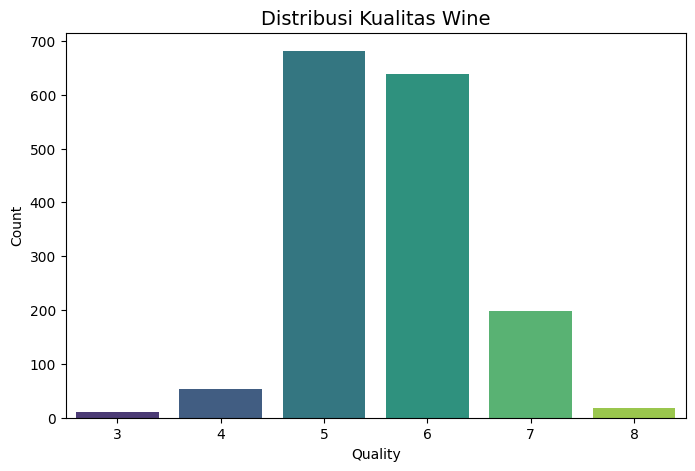


Distribusi kelas quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribusi Kualitas Wine", fontsize=14)
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

print("\nDistribusi kelas quality:")
print(df["quality"].value_counts().sort_index())


## 4.4 Korelasi Antar Fitur


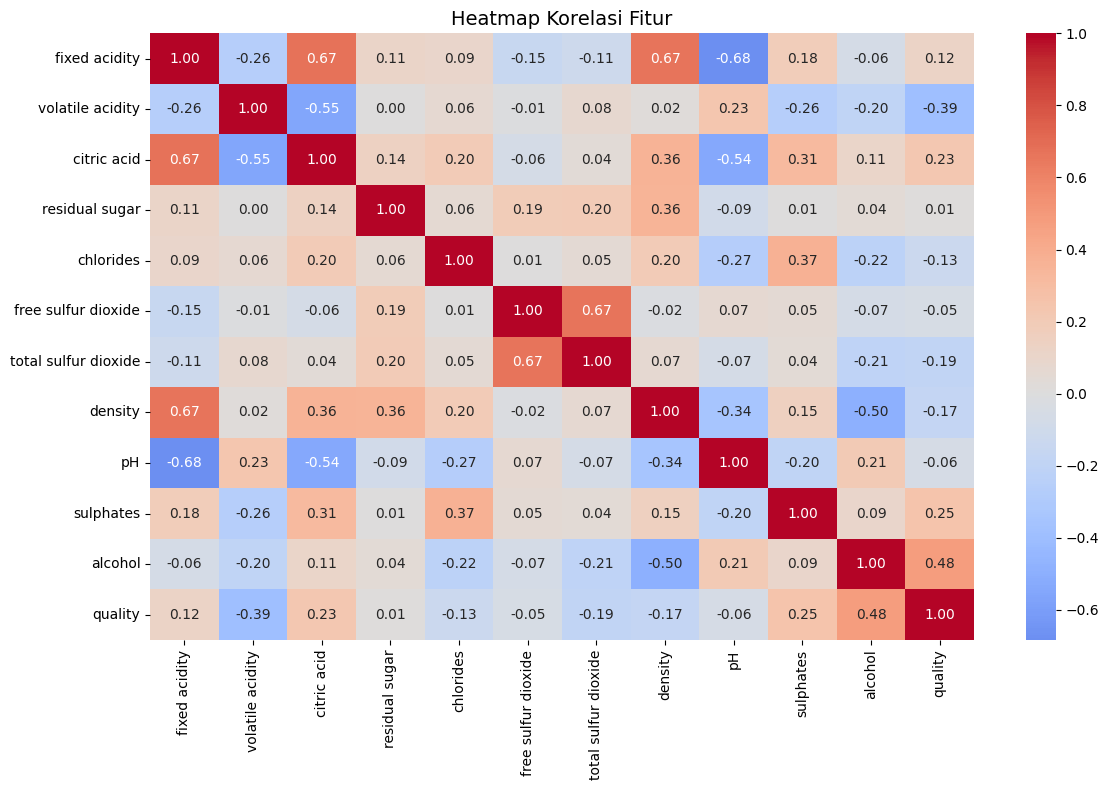

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur", fontsize=14)
plt.tight_layout()
plt.show()


## 4.5 Distribusi Fitur


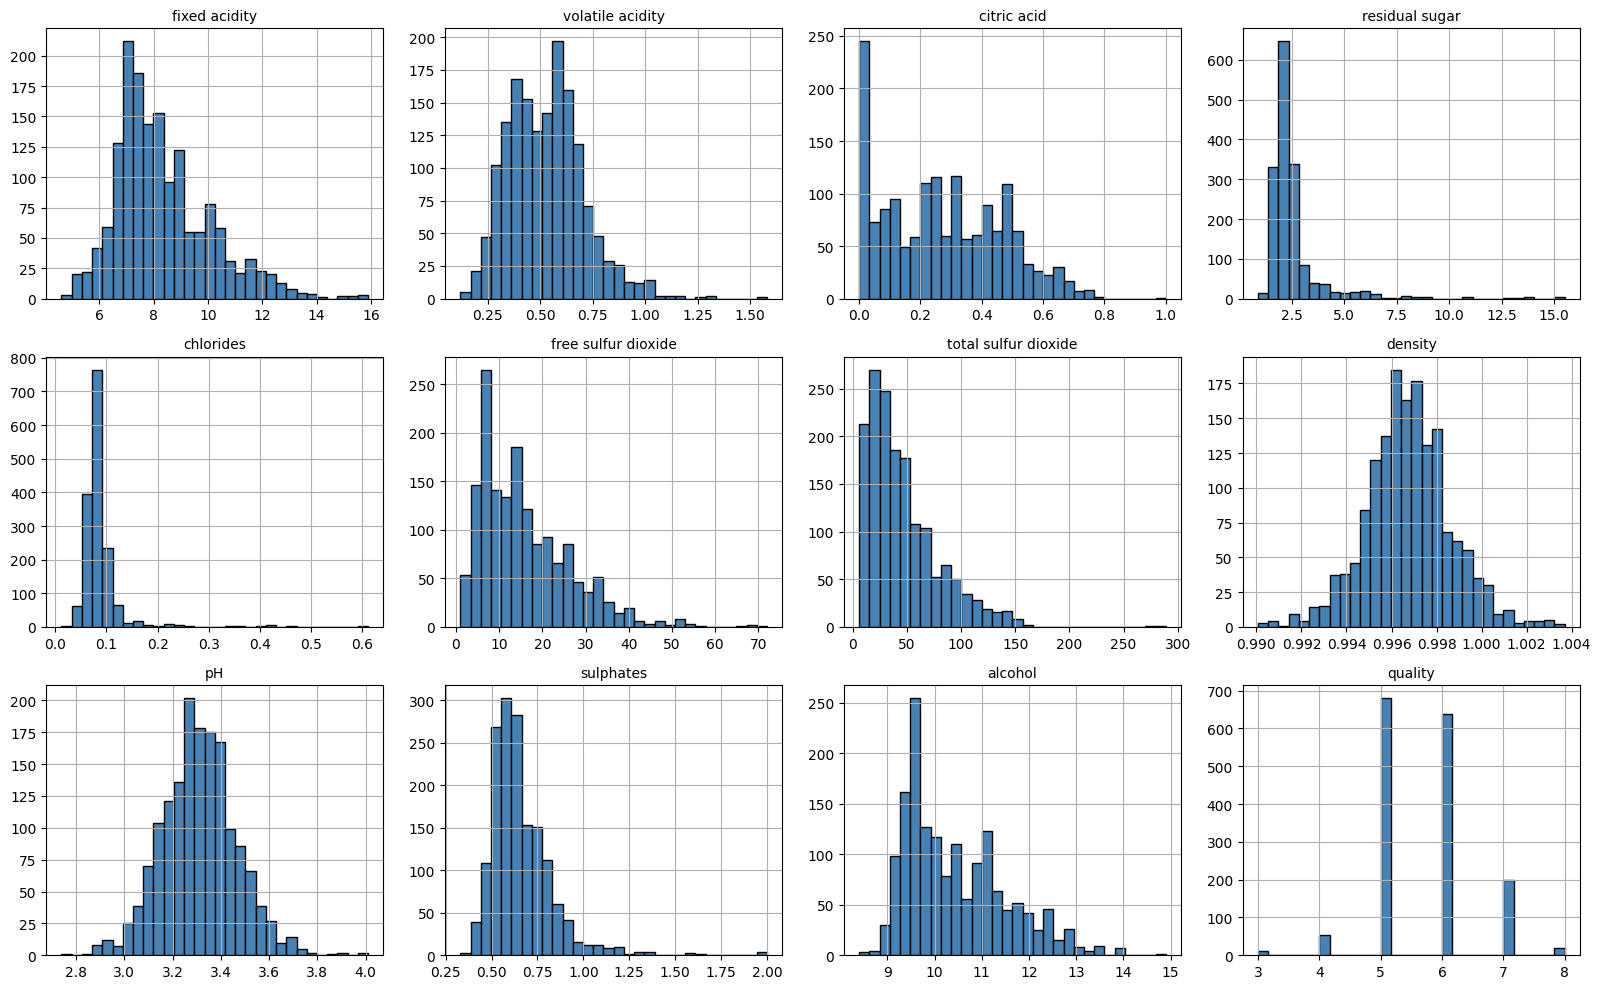

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(df.columns):
    ax = axes[i // 4, i % 4]
    df[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col, fontsize=10)
if len(df.columns) < 12:
    axes[2, 3].set_visible(False)
plt.tight_layout()
plt.show()


## 4.6 Boxplot untuk Deteksi Outlier


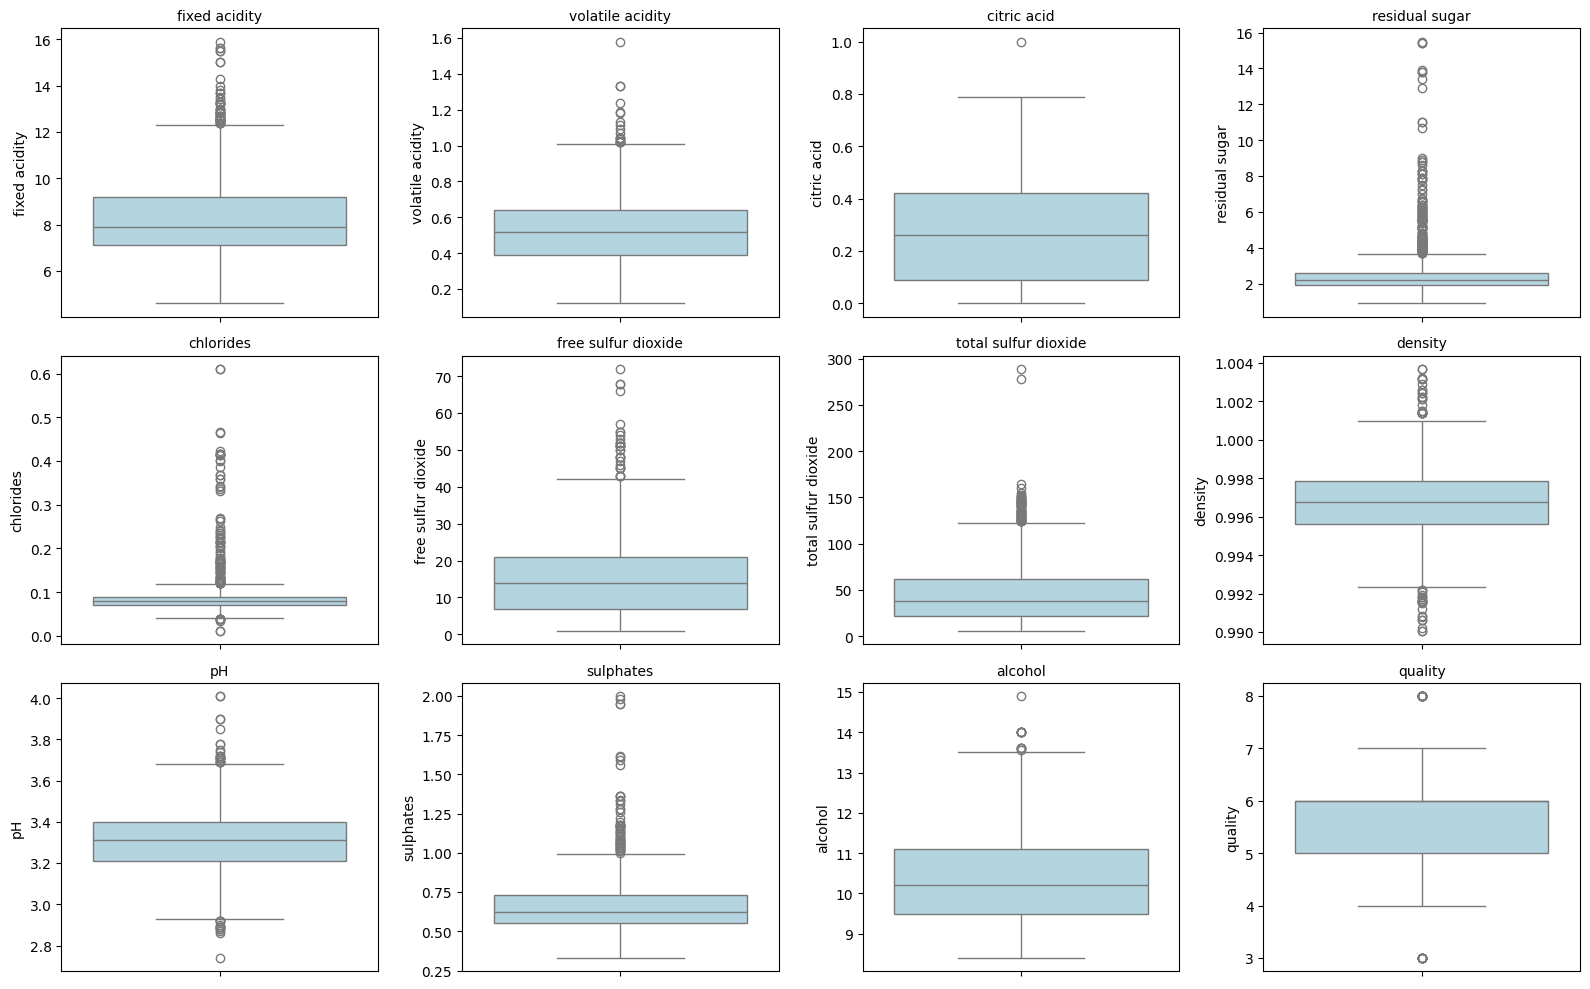

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(df.columns):
    ax = axes[i // 4, i % 4]
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(col, fontsize=10)
if len(df.columns) < 12:
    axes[2, 3].set_visible(False)
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data agar siap digunakan untuk melatih model.


## 5.1 Menghapus Data Duplikat


In [9]:
print(f"Jumlah duplikat sebelum: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Jumlah duplikat sesudah: {df.duplicated().sum()}")
print(f"Shape setelah hapus duplikat: {df.shape}")


Jumlah duplikat sebelum: 240
Jumlah duplikat sesudah: 0
Shape setelah hapus duplikat: (1359, 12)


## 5.2 Menangani Outlier (IQR Method)


In [10]:
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

feature_cols = df.columns.drop("quality")
print(f"Shape sebelum remove outlier: {df.shape}")
df = remove_outliers_iqr(df, feature_cols)
print(f"Shape sesudah remove outlier: {df.shape}")


Shape sebelum remove outlier: (1359, 12)
Shape sesudah remove outlier: (985, 12)


## 5.3 Memisahkan Fitur dan Target


In [11]:
X = df.drop("quality", axis=1)
y = df["quality"]

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")


Shape fitur (X): (985, 11)
Shape target (y): (985,)


## 5.4 Split Data (Train & Test)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (788, 11)
X_test: (197, 11)
y_train: (788,)
y_test: (197,)


## 5.5 Normalisasi Fitur (StandardScaler)


In [13]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Statistik X_train setelah scaling:")
print(X_train_scaled.describe().round(2))


Statistik X_train setelah scaling:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count         788.00            788.00       788.00          788.00   
mean           -0.00             -0.00        -0.00            0.00   
std             1.00              1.00         1.00            1.00   
min            -2.09             -2.40        -1.38           -2.22   
25%            -0.71             -0.78        -0.88           -0.65   
50%            -0.23             -0.00        -0.04           -0.20   
75%             0.60              0.66         0.79            0.70   
max             2.87              2.94         2.46            3.17   

       chlorides  free sulfur dioxide  total sulfur dioxide  density      pH  \
count     788.00               788.00                788.00   788.00  788.00   
mean       -0.00                 0.00                  0.00    -0.00    0.00   
std         1.00                 1.00                  1.00     1.00    1.00   
min  

## 5.6 Menyimpan Dataset Hasil Preprocessing


In [14]:
# Gabungkan kembali untuk disimpan
train_data = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

train_data.to_csv("winequality_preprocessing_train.csv", index=False)
test_data.to_csv("winequality_preprocessing_test.csv", index=False)

print("Dataset preprocessing berhasil disimpan!")
print(f"Train: {train_data.shape}")
print(f"Test: {test_data.shape}")
print(f"NaN check - Train: {train_data.isnull().sum().sum()}, Test: {test_data.isnull().sum().sum()}")


Dataset preprocessing berhasil disimpan!


Train: (788, 12)
Test: (197, 12)
NaN check - Train: 0, Test: 0
